In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [19]:
df = pd.read_csv("mobile_usage_behavioral_analysis.csv")

df.head()

,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,Male,2.61,7.15,24,4.43,0.55,2.40,Los Angeles
1,2,46,Male,2.13,13.79,18,4.67,4.42,2.43,Chicago
2,3,32,Female,7.28,4.50,11,4.58,1.71,2.83,Houston
3,4,25,Female,1.20,6.29,21,3.18,3.42,4.58,Phoenix
4,5,38,Male,6.31,12.59,14,3.15,0.13,4.00,New York


In [28]:
x = df[[
    'Total_App_Usage_Hours',
    'Daily_Screen_Time_Hours',
    'Number_of_Apps_Used',
    'Social_Media_Usage_Hours',
    'Productivity_App_Usage_Hours',
    'Gaming_App_Usage_Hours'
]]

In [29]:
df.describe()

,User_ID,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,38.745000,6.405670,7.696310,16.64700,2.456330,2.495270,2.475410
std,288.819436,12.186734,3.134855,3.714187,7.61961,1.439525,1.443392,1.450362
min,1.000000,18.000000,1.000000,1.010000,3.00000,0.000000,0.000000,0.010000
25%,250.750000,28.000000,3.590000,4.530000,10.00000,1.200000,1.282500,1.220000
50%,500.500000,40.000000,6.455000,7.880000,17.00000,2.445000,2.435000,2.455000
75%,750.250000,50.000000,9.122500,10.910000,23.00000,3.672500,3.710000,3.782500
max,1000.000000,59.000000,11.970000,14.000000,29.00000,4.990000,5.000000,5.000000


In [30]:
df.isnull().sum()

User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64

In [31]:
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)

IQR = Q3 - Q1

x_clean = x[
    ~((x < (Q1 - 1.5 * IQR)) |
      (x > (Q3 + 1.5 * IQR))).any(axis=1)
]

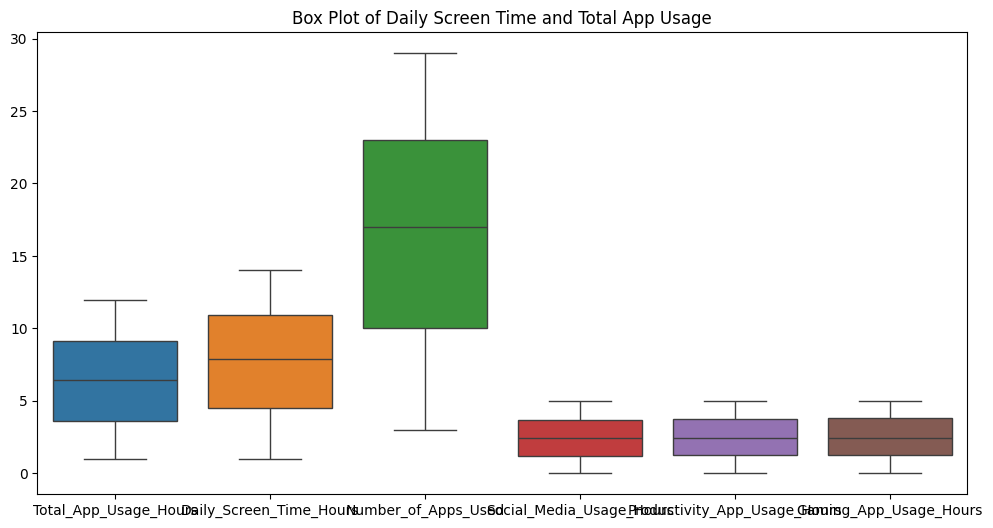

In [32]:
#box plot to visualize outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=x_clean)
plt.title('Box Plot of Daily Screen Time and Total App Usage')
plt.show()

In [33]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x_clean)
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(x_scaled)

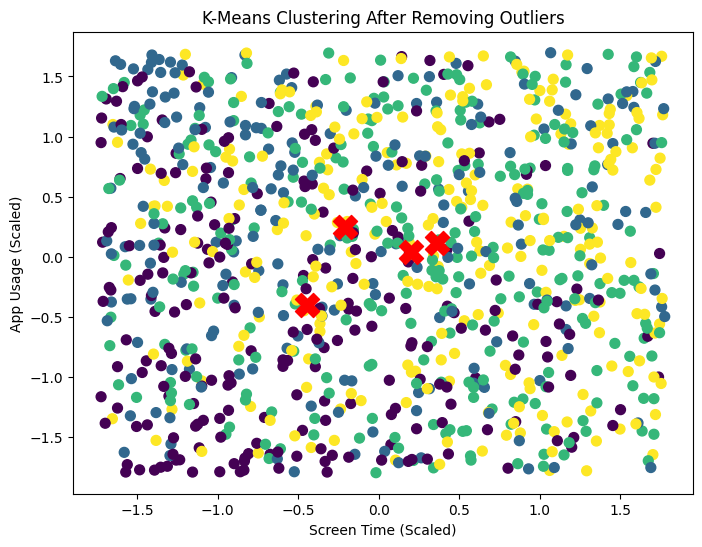

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c=clusters,
    cmap='viridis',
    s=50
)

# Plot Centroids
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='red',
    s=300,
    marker='X'
)

plt.xlabel("Screen Time (Scaled)")
plt.ylabel("App Usage (Scaled)")
plt.title("K-Means Clustering After Removing Outliers")

plt.show()

In [35]:
x_clean['Cluster'] = clusters

x_clean.head()

,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Cluster
0,2.61,7.15,24,4.43,0.55,2.40,2
1,2.13,13.79,18,4.67,4.42,2.43,1
2,7.28,4.50,11,4.58,1.71,2.83,2
3,1.20,6.29,21,3.18,3.42,4.58,1
4,6.31,12.59,14,3.15,0.13,4.00,2


In [36]:
x_clean['Cluster'].value_counts()

Cluster
2    294
3    254
0    234
1    218
Name: count, dtype: int64

In [ ]:
cluster_analysis = x_clean.groupby('Cluster').mean(numeric_only=True)

cluster_analysis

cluster_analysis

KeyError: 'Cluster'